# Whats Cooking Classification: Predicting cuisine based on recipe text data

Project adapted from Professor Anthony Breitzman at Rowan University, Web and Text Mining 2026.

Dataset info: The following models are trained used the cooking_trainfile.json file. It is a text file comprising of (many) rows of recipes, each with a unique id, an associated cuisine (ex: greek) and a list of ingredients comprising that recipe. 

The goal is that with this data, I can train my model(s) to predict cuisines based on the list of ingredients. After training my models, I will then test them with the cooking_testfile.json, which gives ingredients but not cuisine info. 

 I intend to do a lot of pre-processing, exploratory analysis, model selection/comparison, error analysis and evaluation.

 Thanks for reading!

# How should I measure success in my models?

Accuracy - what percentage of all recipes recieved the correct cuisine. Important, but also could be easily skewed if, for example, it is incredibly accurate with Italian cuisine but horribly inaccurate with Brazilian. Italian recipes could outnumber Brazilian, so even if accuracy is great, it shouldn't be my only decision metric.

Precision and Recall - in a binary classification problem, precision and recall are easier to define. In this multiclass assignment, each cuisine is treated as the positive class against all other classes. This makes it harder to justify prioritizing one over the other.

Macro F1 - balances precision/recall, calculates an F1 score for each class (cuisine) separately and takes the average. This will be my **primary success metric.**

Weighted F1 - gives larger cuisines more influence. Comparing this to macro F1 will be very informative to see how smaller cuisines do against larger ones. If similar, then performance is relatively consistent across cuisines (great), - if higher, then smaller cuisines are likely doing worse.

In [113]:
import sys
print(sys.version)

3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:26:47) [MSC v.1942 64 bit (AMD64)]


In [114]:
# Import the required libraries 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import json

# 1. Read Data



In [115]:
def read_dataset(path):
  return json.load(open(path)) 

data = read_dataset('data/cooking_trainfile.json')

In [117]:
#Convert everything to lowercase.  Probably could clean up a little more
def generate_text(data):
  text_data = [" ".join(doc['ingredients']).lower() for doc in data]
  return text_data 

In [118]:
X = generate_text(data)
Y = [doc['cuisine'] for doc in data]

Before I continue cleaning data I would like to do some Exploratory Data Analysis to better understand what I'm working with. This will help me with cleaning, preprocessing, modeling and analysis.

# 2. Exploratory Data Analysis

In [120]:
cuisine_counts = pd.Series(Y).value_counts()
cuisine_distribution = pd.DataFrame({
    "Count": pd.Series(Y).value_counts(),
    "Percentage": (pd.Series(Y).value_counts(normalize=True) * 100).round(2)
})

print(cuisine_distribution)
print("\ntotal recipes:", cuisine_counts.sum())

              Count  Percentage
italian        6308       19.83
mexican        5178       16.27
southern_us    3461       10.88
indian         2364        7.43
chinese        2121        6.67
french         2115        6.65
thai           1230        3.87
cajun_creole   1229        3.86
japanese       1159        3.64
greek           943        2.96
spanish         802        2.52
vietnamese      662        2.08
british         650        2.04
korean          644        2.02
moroccan        617        1.94
filipino        615        1.93
irish           529        1.66
jamaican        421        1.32
brazilian       386        1.21
russian         384        1.21

total recipes: 31818


Most represented cuisines: Italian, Mexican, Southern_US

Least represented: Jamaican, Brazilian, Russian

Visualization:

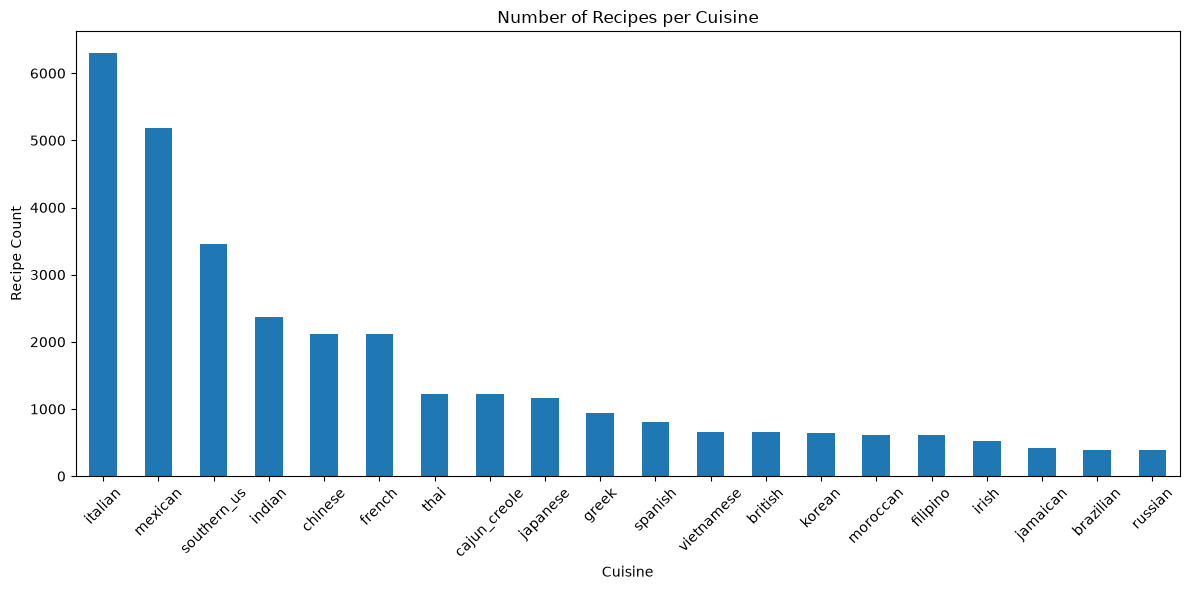

In [121]:
plt.figure(figsize=(12,6))
cuisine_counts.plot(kind="bar")

plt.title("Number of Recipes per Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Recipe Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 3. Preprocessing

In [146]:
print ("Divide into training and validation sets")
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

Divide into training and validation sets


In [147]:
# Decided to use reg ex library (https://docs.python.org/3/library/re.html)
# Wanted to do this to "group words"
# For example, I noticed a couple ingredients consist of two words, but they 
# aren't connected via underscore, so they're treated differently.
# ex: soy and sauce should be one token
# Also, some ingredients are the same thing. Like cilantro and coriander.


import re

_PATTS = [
    # Cilantro is coriander, decided to group these two
    (re.compile(r"\bcoriander\b", re.I), "cilantro"),
    # scallions, spring onions, green onions should all be grouped into green_onion
    (re.compile(r"\b(scallions?|spring\s+onions?|green\s+onions?)\b", re.I), "green_onion"),
    # soy and sauce should be one phrase, soy_sauce
    (re.compile(r"\bsoy\s+sauce\b", re.I), "soy_sauce"),
    # fish sauce -> fish_sauce
   # (re.compile(r"\bfish\s+sauce\b", re.I), "fish_sauce"),
    

    ## *I noticed accuracy for Jamaican was quite low (.15 accuracy on CM, confused
    ## with korean and russian, so I added some re.compiles for its cuisine
   (re.compile(r"\bjerk(\s+seasoning)?\b", re.I), "jerk_seasoning"),
  
    

    
]

In [148]:
def preprocess(s: str) -> str:
    s = s.lower()
    for rx, rep in _PATTS:
        s = rx.sub(rep, s)
    return s

In [149]:
for i in range(5):
    print("Cuisine:", Y[i])
    print("Original:", data[i]["ingredients"])
    print("Processed:", X[i])
    print()

Cuisine: greek
Original: ['black peppercorns', 'crushed red pepper', 'fresh ginger', 'garlic cloves', 'olive oil', 'cumin seed', 'fennel seeds', 'cardamom seeds', 'leg of lamb']
Processed: romaine lettuce black olives grape tomatoes garlic pepper purple onion seasoning garbanzo beans feta cheese crumbles

Cuisine: filipino
Original: ['eggs', 'zucchini', 'pinto beans', 'chorizo sausage', 'olive oil', 'tomatoes with juice', 'onions', 'cooked rice', 'lean ground beef', 'chopped cilantro', 'ground cumin', 'ground black pepper', 'fine sea salt', 'dried oregano']
Processed: eggs pepper salt mayonaise cooking oil green chilies grilled chicken breasts garlic powder yellow onion soy sauce butter chicken livers

Cuisine: indian
Original: ['chicken broth', 'unsalted butter', 'garlic', 'ground cayenne pepper', 'lump crab meat', 'clam juice', 'all-purpose flour', 'white corn', 'green onions', 'salt', 'onions', 'dried thyme', 'heavy cream', 'ground white pepper']
Processed: water vegetable oil wheat

In [150]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Built a modeling pipeleine, the TfidfVectorizer turns text numeric
# min_df = 4, so this ignores words that appear in fewer than 4 documents 
# min_df of 4 gave me the best test accuracy and had the best CM 
# Linear SVC (support vector classification)
# implements the preprocessor function from last cell
# ngram_range of 1,1 (1,2 yielded worse results)
# * class weight balanced because I noticed that cuisines like Italian or Thai had high accuracy,
# but other cuisines were very inaccurately matched
pipe = Pipeline([
    ("vec", TfidfVectorizer(
        preprocessor = preprocess,                 
        token_pattern=r"(?u)\b\w[\w_]+\b",          
        min_df=1, ngram_range=(1,1)
    )),
    ("clf", LinearSVC(C=1.0))
])

param_grid = {"clf__C": [0.5, 1.0, 2.0]}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, param_grid, cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Test accuracy:", gs.score(X_test, y_test))

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params: {'clf__C': 0.5}
Test accuracy: 0.7969830295411691


In [151]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
y_pred = gs.best_estimator_.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted", zero_division=0))
print("Macro Precision:", precision_score(y_test, y_pred, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_test, y_pred, average="macro", zero_division=0))

Accuracy: 0.7969830295411691
Macro F1: 0.7284015787947627
Weighted F1: 0.7930599360062223
Macro Precision: 0.7689485006442551
Macro Recall: 0.7012211642619266


Overall all metrics are >.70 which I'm happy with so far.

Weighted F1 is .07 points above Macro F1 which indicates that smaller cuisines are doing worse. I would like to smooth this out.

*Note: Least represented cuisines: Jamaican, Brazilian, Russian

Let us look at a classification report for every cuisine.

In [153]:
from sklearn.metrics import classification_report

print(
    classification_report(y_test, y_pred, digits=3, zero_division=0)
)

              precision    recall  f1-score   support

   brazilian      0.854     0.477     0.612        86
     british      0.653     0.467     0.545       137
cajun_creole      0.750     0.757     0.753       222
     chinese      0.828     0.878     0.852       427
    filipino      0.654     0.581     0.615       117
      french      0.626     0.642     0.634       433
       greek      0.796     0.701     0.746       184
      indian      0.863     0.895     0.879       459
       irish      0.667     0.453     0.539       106
     italian      0.820     0.896     0.856      1283
    jamaican      0.868     0.868     0.868        68
    japanese      0.883     0.690     0.775       229
      korean      0.814     0.750     0.780       128
     mexican      0.900     0.926     0.913      1051
    moroccan      0.870     0.799     0.833       134
     russian      0.686     0.530     0.598        66
 southern_us      0.722     0.791     0.755       724
     spanish      0.664    

# EVERY THING PAST HERE MUST BE REORGANIZED

In [138]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Built a modeling pipeleine, the TfidfVectorizer turns text numeric
# min_df = 4, so this ignores words that appear in fewer than 4 documents 
# min_df of 4 gave me the best test accuracy and had the best CM 
# Linear SVC (support vector classification)
# implements the preprocessor function from last cell
# ngram_range of 1,1 (1,2 yielded worse results)
# * class weight balanced because I noticed that cuisines like Italian or Thai had high accuracy,
# but other cuisines were very inaccurately matched
pipe = Pipeline([
    ("vec", TfidfVectorizer(
        preprocessor = preprocess,                 
        token_pattern=r"(?u)\b\w[\w_]+\b",          
        min_df=1, ngram_range=(1,1)
    )),
    ("clf", LinearSVC(C=1.0))
])

param_grid = {"clf__C": [0.5, 1.0, 2.0]}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, param_grid, cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Test accuracy:", gs.score(X_test, y_test))


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params: {'clf__C': 0.5}
Test accuracy: 0.7933689503456945


In [139]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
y_pred = gs.best_estimator_.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted", zero_division=0))
print("Macro Precision:", precision_score(y_test, y_pred, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_test, y_pred, average="macro", zero_division=0))


Accuracy: 0.7933689503456945
Macro F1: 0.715635671498718
Weighted F1: 0.7877575108846235
Macro Precision: 0.7665388039070138
Macro Recall: 0.6840795214889973


In [140]:
import warnings
warnings.filterwarnings("ignore")  #not a great idea in general, but it cleans up the output when using scikit-learn
#obviously anything that triggers an error won't get ignored

from sklearn.neighbors import KNeighborsClassifier

In [141]:
#let's look at 20 predictions

for i in range(20):
    print(X_test[i],'|',y_test[i],'|',y_pred[i],'\n')

fresh oregano leaves calamata olives fresh thyme leaves all-purpose flour tomatoes olive oil shredded swiss cheese garlic tomato paste pepper large eggs butter anchovy fillets fresh marjoram dijon mustard shallots salt | french | french 

honey hellmann or best food real mayonnais garlic bread crumb fresh salt pork chops, 1 inch thick | southern_us | italian 

chicken stock lemon grass fresh mushrooms fish sauce clove garlic, fine chop fillets fresh basil tom yum paste lime leaves fresh coriander green chilies fresh lime juice | thai | thai 

pepper cabbage salt bacon white sugar | southern_us | southern_us 

shredded cheddar cheese tomato salsa iceberg lettuce cooked chicken salt flour tortillas clove garlic, fine chop vegetable oil onions | mexican | mexican 

water sweetened condensed milk sticky rice semisweet chocolate kosher salt heavy cream | filipino | vietnamese 

garlic powder salt cabbage potatoes sweet paprika chicken pepper onion powder thyme water bacon onions | irish | s

In [142]:
class_names =[]
for i in range(len(y_test)):
    if y_test[i] not in class_names:
        class_names.append(y_test[i])

In [143]:
import matplotlib.pyplot as plt
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

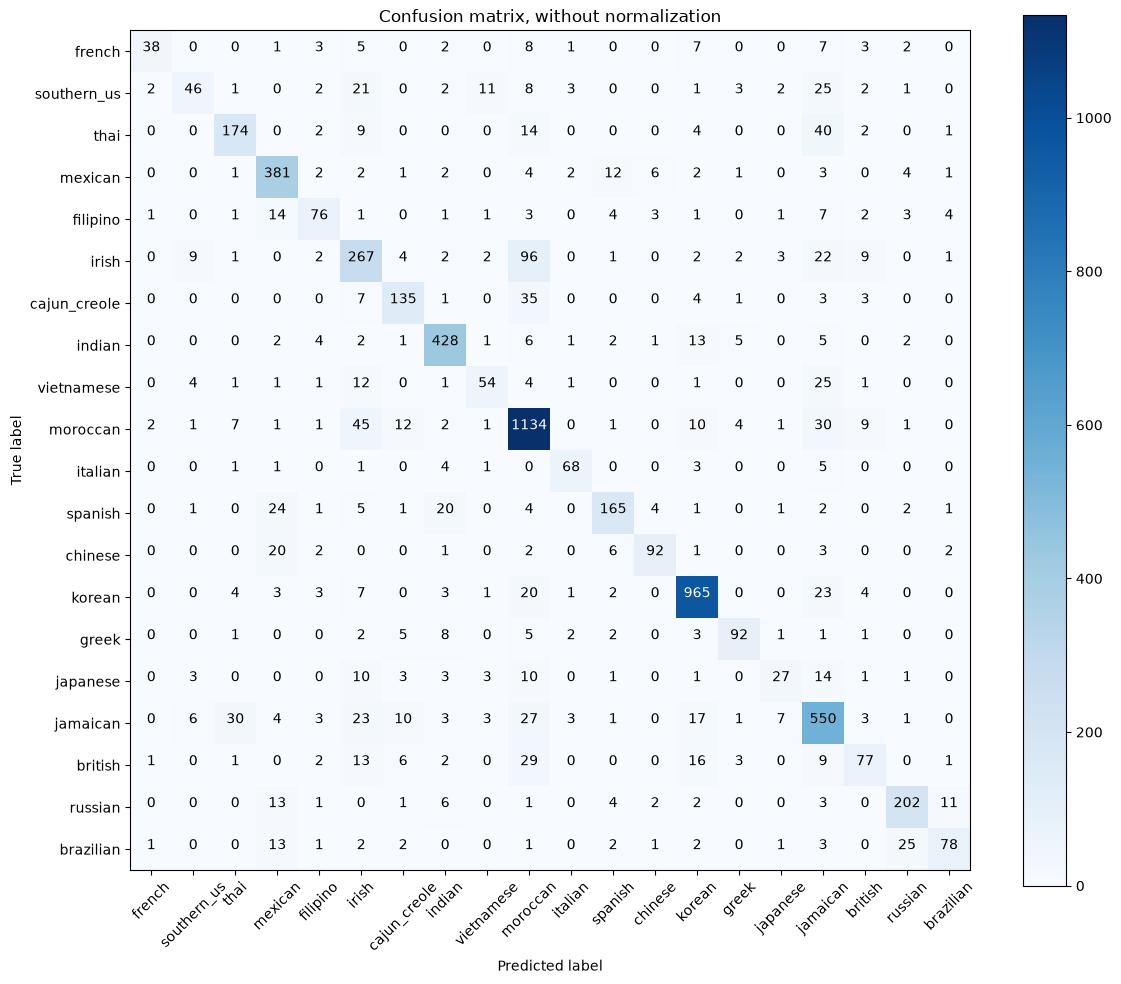

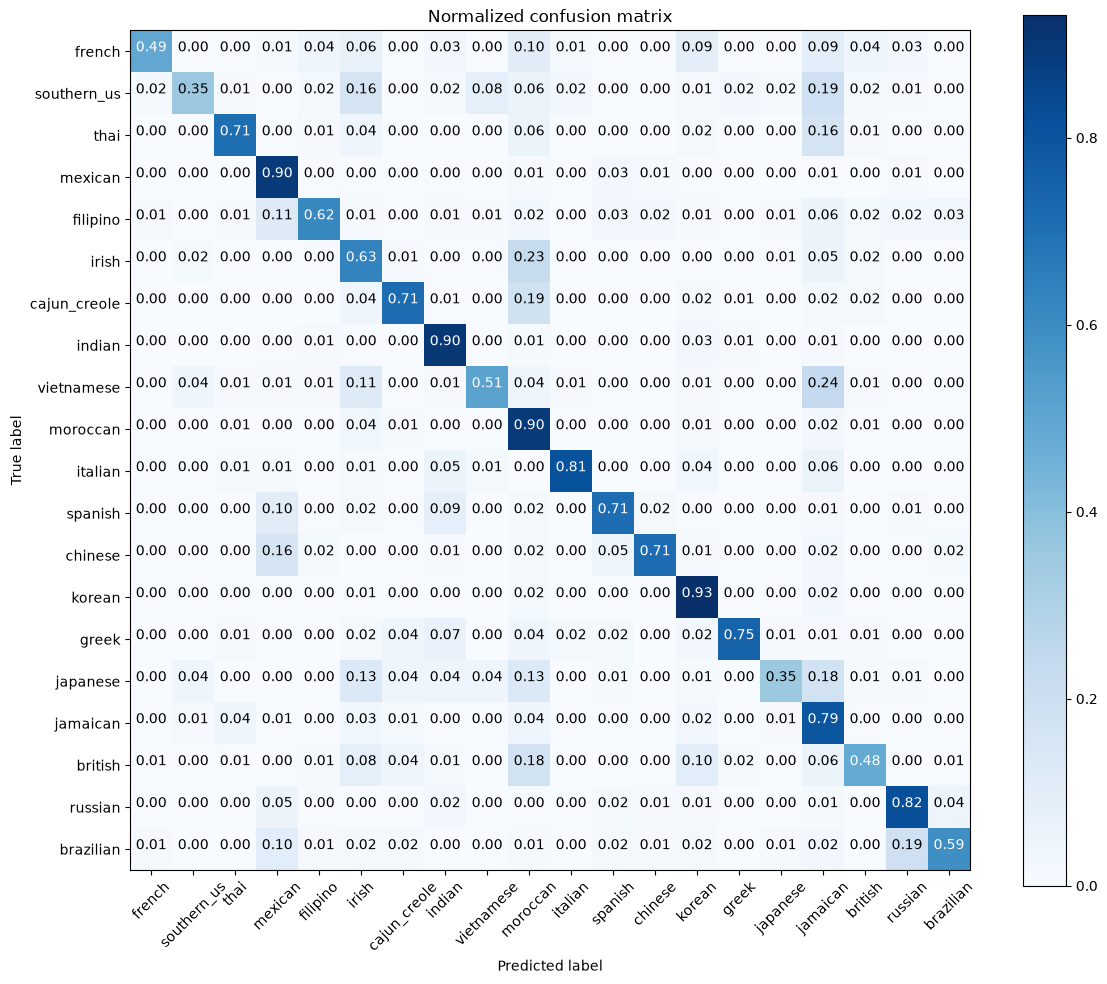

In [144]:


from sklearn.metrics import confusion_matrix
import numpy as np

cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure(figsize=(12, 10))
plot_confusion_matrix(cnf_matrix, classes=class_names,
                      title='Confusion matrix, without normalization')

#plt.savefig("figure1.pdf", dpi="figure")
# Plot normalized confusion matrix
plt.figure(figsize=(12, 10))
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='Normalized confusion matrix')

#plt.savefig("figure2.pdf", dpi="figure")
plt.show()

In [145]:
import json, pandas as pd
import csv

with open("data/cooking_testfile.json", "r", encoding="utf-8") as f:
    data = json.load(f)

ids   = [d["id"] for d in data]
texts = [", ".join(d["ingredients"]) for d in data]  # <-- was the bug

best = gs.best_estimator_
pred = best.predict(texts)
out = pd.DataFrame({"id": ids, "cuisine": pred})

# Creates new output file, uncomment to download
#out.to_csv("data/cooking_output.csv", index=False)
print("Wrote cooking_output.csv with", len(out), "rows; last id:", out.iloc[-1,0])



Wrote cooking_output.csv with 7955 rows; last id: 905668
